# CIS6005 Computational Intelligence
## Notebook 01 — Environment Check
**Student Health Risk Prediction | Kaggle PS S6E7**

---

### Purpose
This notebook verifies that all required libraries are installed correctly and reports their versions.
Run this FIRST before any other notebook.

> **Rule:** Never build on a broken environment. Always verify first.

## 1. Import All Required Libraries

**Why:** We test every single import here. If any import fails, we know exactly which library is missing BEFORE we start the project — not halfway through.

**How:** We import each library and print its version number.

In [1]:
# ============================================================
# SECTION 1: Library Version Check
# Run this cell first to verify your environment is ready.
# ============================================================

import sys
import warnings
warnings.filterwarnings('ignore')

# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- Visualisation Libraries ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning Libraries ---
import sklearn
import joblib

# --- Print Version Report ---
print('=' * 55)
print('  CIS6005 — Environment Verification Report')
print('=' * 55)
print(f'  Python        : {sys.version.split("|")[0].strip()}')
print(f'  Pandas        : {pd.__version__}')
print(f'  NumPy         : {np.__version__}')
print(f'  Matplotlib    : {matplotlib.__version__}')
print(f'  Seaborn       : {sns.__version__}')
print(f'  Scikit-learn  : {sklearn.__version__}')
print(f'  Joblib        : {joblib.__version__}')
print('=' * 55)
print(' All libraries imported successfully!')
print('=' * 55)

  CIS6005 — Environment Verification Report
  Python        : 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
  Pandas        : 2.3.3
  NumPy         : 2.3.5
  Matplotlib    : 3.10.8
  Seaborn       : 0.13.2
  Scikit-learn  : 1.8.0
  Joblib        : 1.5.2
 All libraries imported successfully!


## 2. Verify Project Directory Structure

**Why:** We confirm the project folders exist before trying to read or write files. This prevents `FileNotFoundError` later.

**How:** We use Python's `pathlib` module — the modern, cross-platform way to handle file paths.

In [2]:
# ============================================================
# SECTION 2: Project Directory Verification
# Confirms all required folders exist.
# ============================================================

from pathlib import Path

# Define the project root (one level up from /notebooks/)
PROJECT_ROOT = Path.cwd().parent

# Define all expected directories
required_dirs = [
    'data/raw',
    'data/processed',
    'data/submissions',
    'notebooks',
    'models',
    'streamlit_app',
    'report',
    'presentation'
]

print('=' * 55)
print('  Project Directory Check')
print(f'  Root: {PROJECT_ROOT}')
print('=' * 55)

all_good = True
for folder in required_dirs:
    full_path = PROJECT_ROOT / folder
    status = ' EXISTS' if full_path.exists() else 'MISSING'
    if not full_path.exists():
        all_good = False
    print(f'  {status}  →  {folder}')

print('=' * 55)
if all_good:
    print('   All directories are in place. Ready to proceed!')
else:
    print('  Some directories are missing. Run setup step again.')
print('=' * 55)

  Project Directory Check
  Root: d:\Student_Health_Risk_Prediction
   EXISTS  →  data/raw
   EXISTS  →  data/processed
   EXISTS  →  data/submissions
   EXISTS  →  notebooks
   EXISTS  →  models
   EXISTS  →  streamlit_app
   EXISTS  →  report
   EXISTS  →  presentation
   All directories are in place. Ready to proceed!


## 3. Quick Sanity Tests

**Why:** We run a very small NumPy and Pandas operation to confirm that the libraries don't just *import* but actually *work* correctly.

**How:** Create a tiny dummy DataFrame and perform a basic operation — if this passes, your stack is fully functional.

  NumPy test     → ✅ Mean of [1,2,3,4,5] = 3.0
  Pandas test    → ✅ DataFrame created: 3 rows, 2 cols


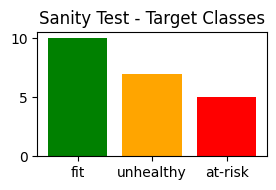

  Matplotlib test → ✅ Plot rendered and saved successfully
  Sklearn test   → ✅ LabelEncoder works: [np.str_('at-risk'), np.str_('fit'), np.str_('unhealthy')] → [np.int64(1), np.int64(2), np.int64(0)]

  ✅ ALL SANITY TESTS PASSED. Environment is ready!


In [3]:
# ============================================================
# SECTION 3: Quick Sanity Tests
# Runs tiny operations to confirm libraries work.
# ============================================================

# --- Test NumPy ---
arr = np.array([1, 2, 3, 4, 5])
assert arr.mean() == 3.0, 'NumPy mean calculation failed!'
print(f'  NumPy test     → ✅ Mean of [1,2,3,4,5] = {arr.mean()}')

# --- Test Pandas ---
dummy_df = pd.DataFrame({
    'student_id': [1, 2, 3],
    'health_condition': ['fit', 'unhealthy', 'at-risk']
})
assert dummy_df.shape == (3, 2), 'Pandas DataFrame shape mismatch!'
print(f'  Pandas test    → ✅ DataFrame created: {dummy_df.shape[0]} rows, {dummy_df.shape[1]} cols')

# --- Test Matplotlib ---
fig, ax = plt.subplots(figsize=(3, 2))
ax.bar(['fit', 'unhealthy', 'at-risk'], [10, 7, 5], color=['green', 'orange', 'red'])
ax.set_title('Sanity Test - Target Classes')
plt.tight_layout()
plt.savefig('../data/processed/sanity_test_plot.png', dpi=72)
plt.show()
print('  Matplotlib test → ✅ Plot rendered and saved successfully')

# --- Test Scikit-learn ---
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encoded = le.fit_transform(['fit', 'unhealthy', 'at-risk'])
print(f'  Sklearn test   → ✅ LabelEncoder works: {list(le.classes_)} → {list(encoded)}')

print('\n  ✅ ALL SANITY TESTS PASSED. Environment is ready!')

## 4. Kaggle Dataset Download Instructions

**Why:** You need the competition data before you can do anything. This section explains exactly how to get it.

---

### Method A — Manual Download (Recommended for Beginners)

1. Go to: https://www.kaggle.com/competitions/playground-series-s6e7
2. Accept the competition rules (click **'Join Competition'**)
3. Click the **'Data'** tab
4. Download these files:
   - `train.csv` → Save to `data/raw/train.csv`
   - `test.csv` → Save to `data/raw/test.csv`
   - `sample_submission.csv` → Save to `data/raw/sample_submission.csv`

---

### Method B — Kaggle API (Advanced)

If you have the Kaggle API configured, run the cell below.

In [4]:
# ============================================================
# SECTION 4: Kaggle API Download (Optional)
# Only run this if you have kaggle.json configured.
# Otherwise, download manually from kaggle.com.
# ============================================================

import subprocess
import os

# Set the download target folder
raw_data_path = str(PROJECT_ROOT / 'data' / 'raw')

# Attempt Kaggle API download
try:
    result = subprocess.run(
        [
            'kaggle', 'competitions', 'download',
            '-c', 'playground-series-s6e7',
            '-p', raw_data_path,
            '--unzip'
        ],
        capture_output=True,
        text=True,
        timeout=120
    )
    if result.returncode == 0:
        print('✅ Kaggle API download successful!')
        print(result.stdout)
    else:
        print('❌ Kaggle API failed. Please download manually from kaggle.com.')
        print(result.stderr)
except FileNotFoundError:
    print('⚠️  Kaggle CLI not found.')
    print('   → Please download the dataset manually from kaggle.com')
    print(f'   → Save files to: {raw_data_path}')
except Exception as e:
    print(f'⚠️  Error: {e}')
    print('   → Please download the dataset manually from kaggle.com')

❌ Kaggle API failed. Please download manually from kaggle.com.



## 5. Confirm Data Files Are Present

**Run this after downloading the dataset.** This confirms you have the right files before moving to Phase 2.

In [5]:
# ============================================================
# SECTION 5: Data File Verification
# Run AFTER downloading the dataset from Kaggle.
# ============================================================

# Expected data files
expected_files = [
    'data/raw/train.csv',
    'data/raw/test.csv',
    'data/raw/sample_submission.csv'
]

print('=' * 55)
print('  Data File Verification')
print('=' * 55)

all_found = True
for file_path in expected_files:
    full_path = PROJECT_ROOT / file_path
    if full_path.exists():
        size_kb = full_path.stat().st_size / 1024
        print(f'  ✅ FOUND    → {file_path} ({size_kb:.1f} KB)')
    else:
        print(f'  ❌ MISSING  → {file_path}')
        all_found = False

print('=' * 55)
if all_found:
    print('  ✅ All data files found. Ready for Phase 2!')
else:
    print('  ❌ Download missing files from kaggle.com/competitions/playground-series-s6e7')
print('=' * 55)

  Data File Verification
  ✅ FOUND    → data/raw/train.csv (61233.5 KB)
  ✅ FOUND    → data/raw/test.csv (23996.2 KB)
  ✅ FOUND    → data/raw/sample_submission.csv (4332.3 KB)
  ✅ All data files found. Ready for Phase 2!


---

## ✅ Phase 1 Complete

Once all cells above show green checkmarks:
- ✅ Libraries verified
- ✅ Directories confirmed
- ✅ Sanity tests passed
- ✅ Dataset downloaded

**→ Tell your mentor 'Next' to proceed to Phase 2: Dataset Understanding**